# Image Generation Tool: агент-художник внутри Responses API

Ещё одним встроенным инструментов агентов в AI Studio является [инструмент генерации изображений](https://aistudio.yandex.ru/docs/ru/ai-studio/concepts/agents/tools/image-generation.html) - он позволяет добавить генерацию прямо в вызов Responses API, позволяя избежать отдельного кода для вызова `client.image.create` для генерации изображений.

 В этом ноутбуке мы повторим идею из лабораторной работы раздела 2 по рисованию изображений по заданной концепции. Агент получает короткую концепцию, сам превращает её в подробное визуальное описание, вызывает Image Generation Tool, а затем мультимодальная модель Qwen3.6 оценивает результат и предлагает улучшения.

In [ ]:
%pip install --quiet openai pillow python-dotenv


> **ВНИМАНИЕ**: после установки библиотек рекомендуется перезапустить Kernel ноутбука.


In [ ]:
!curl -o .env {{url_of_dotenv_file}}


In [2]:
import base64
import json
import os
from pathlib import Path

from dotenv import load_dotenv
from IPython.display import Image, Markdown, display
from openai import OpenAI

load_dotenv()

folder_id = os.environ["folder_id"]
api_key = os.environ["api_key"]

# Qwen3.6 используем для текстового планирования и мультимодальной оценки изображения.
model = f"gpt://{folder_id}/qwen3.6-35b-a3b/latest"

client = OpenAI(
    base_url="https://ai.api.cloud.yandex.net/v1",
    api_key=api_key,
    project=folder_id,
)

def printx(text):
    display(Markdown(text))

output_dir = Path.cwd() / "generated_images"
output_dir.mkdir(parents=True, exist_ok=True)

print(f"✅ Авторизация настроена (folder_id: {folder_id[:8]}...)")


✅ Авторизация настроена (folder_id: b1gbicod...)


## 1. Генерируем образ по короткой концепции

Пользователь пишет одно слово — например, `счастье`. Агент должен сам решить, как это изобразить: выбрать сцену, стиль, свет, композицию и настроение. Для генерации изображения в Responses API добавляем инструмент `image_generation`.


In [3]:
image_generation_tool = {
    "type": "image_generation",
    "size": "1024x1024",
}

artist_instructions = """
Ты — арт-директор и промпт-инженер.

Когда пользователь даёт короткую абстрактную концепцию:
1. Преврати её в конкретную визуальную сцену.
2. Используй инструмент image_generation для создания изображения.
3. В ответе кратко объясни, какую метафору ты выбрал.
4. Не проси пользователя уточнять стиль, сделай сильный художественный выбор сам.
"""

concept = "счастье"

generation_response = client.responses.create(
    model=model,
    store=True,
    instructions=artist_instructions,
    input=f"Создай изображение на тему: {concept}",
    tools=[image_generation_tool],
)

printx(generation_response.output_text)






На изображении представлена метафора счастья как **момент внутреннего-opening и свободы**.

Вместо классического изображения улыбающихся людей, я выбрал абстрактную сюрреалистичную сцену:
*   **Фигура в позе медитации** символизирует состояние спокойствия и гармонии с собой.
*   **Сидение на облаке** означает отстраненность от наземных забот и «полет».
*   **Излучающий свет шар и бабочки**, вылетающие из него, визуализируют идею о том, что счастье рождается изнутри и трансформируется в свободу и красоту.

Я использовал мягкую 3D-эстетику с нежными пастельными тонами, чтобы передать ощущение мечтательности и чистого, невинного рая.

Для получения доступа к сгенерированным изображениям, используем другие поля ответа модели `response.output`: 

In [4]:
def save_generated_images(response, directory=output_dir, prefix="image"):
    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=True)
    saved = []

    for item in response.output:
        if item.type == "image_generation_call":
            print("Image generation status:", getattr(item, "status", None))
            print("Generated file_id:", getattr(item, "file_id", None))

            if getattr(item, "result", None):
                image_bytes = base64.b64decode(item.result)
                path = directory / f"{prefix}_{len(saved) + 1}.png"
                path.write_bytes(image_bytes)
                saved.append(path)

    return saved

generated_paths = save_generated_images(generation_response, prefix="happiness_v1")
generated_paths


Image generation status: completed
Generated file_id: fvtbjf059cq4orm4d648


[WindowsPath('d:/GIT/ai-studio-course/5-other-int-tools/generated_images/happiness_v1_1.png')]

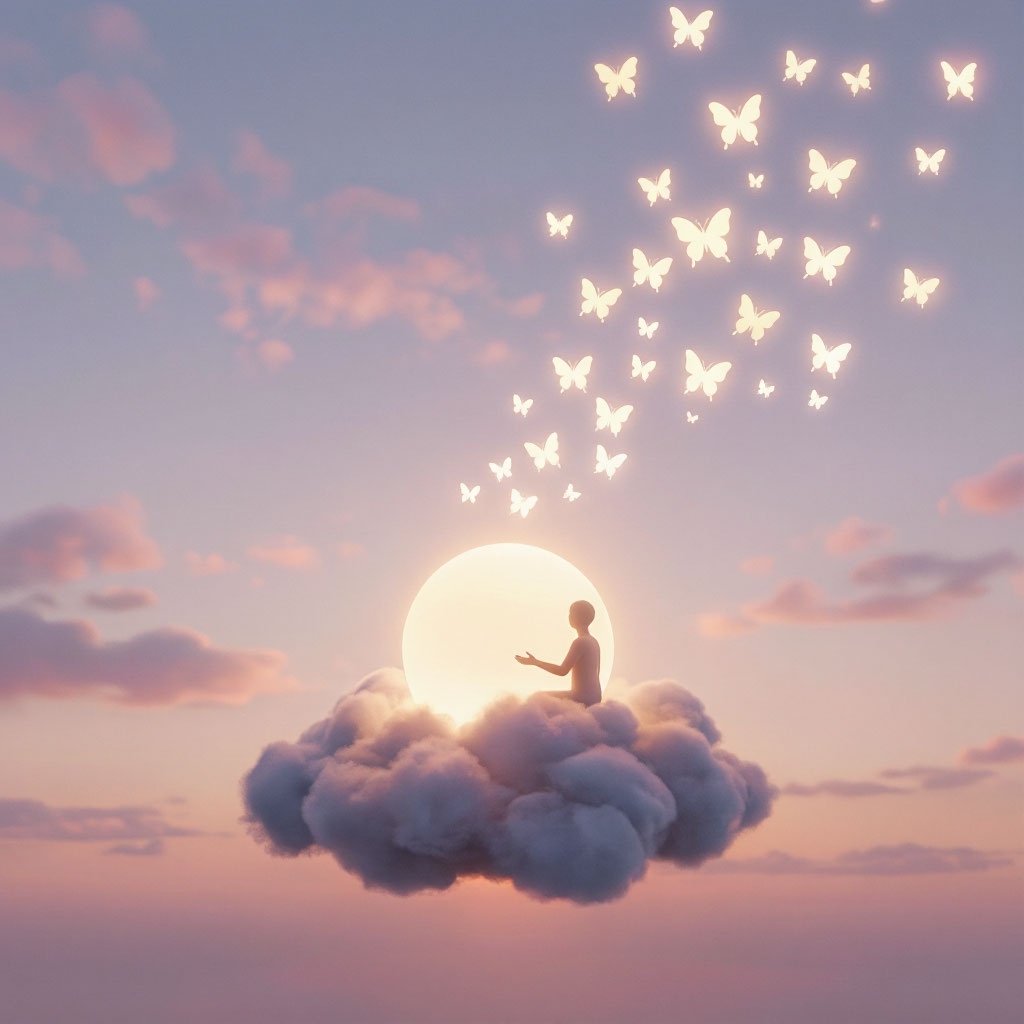

In [5]:
first_image_path = generated_paths[0]
display(Image(filename=str(first_image_path)))


## 2. Совмещаем рисование с оценкой изобажений 

Мы можем попросить агента самостоятельно оценивать изображение, если он использует мультимодальную модель, такую, как Qwen3.6. Модель вернёт оценку и рекомендации, и сможет самостоятельно учеть эти рекомендации для улучшения результата.


In [10]:
image_generation_tool = {
    "type": "image_generation",
    "size": "1024x1024",
}

artist_instructions = """
Ты — художник и промпт-инженер, который любит рисовать картины по заданным абстрактным концепциям.

Пользователь на входе даёт короткую абстрактную концепцию.
1. Преврати её в конкретную визуальную сцену.
2. Используй инструмент image_generation для создания изображения.
3. Далее самостоятельно посмотри на это изображение с помощью мультимодальной модели, оцени его соответсвие концепции по шкале от 0 до 10, и напиши список возможных улучшений.
4. Продолжай делать улучшения до тех пор, пока ты не будешь удовлетворён результатом.
"""

concept = "счастье"

generation_response = client.responses.create(
    model=model,
    store=True,
    instructions=artist_instructions,
    input=f"Создай изображение на тему: {concept}",
    tools=[image_generation_tool],
)

printx(generation_response.output_text)






✨ **Анализ изображения 1:**
Концепция передана хорошо. Динамика движения, профиль "золотого часа" и открытость позы — классический и понятный визуальный код счастья. Свечение добавляет магии.
**Оценка:** 7/10.
**Список улучшений:**
1.  **Избежать "пластиковости":** Магические огоньки (orbs) иногда выглядят искусственно. Попробую сделать акцент на более реалистичном и осязаемом тепле.
2.  **Сила эмоции:** Нужно, чтобы улыбка выглядела неотразимой и искренней, передающей тот самый момент "экстаза".
3.  **Акцент на качества:** Четкость лица и проработка света (backlight) сделают картинку более кинематографичной.

*Перехожу к уточненной версии, где мы уберем фэнтези-элементы и сделаем упор на "человеческое тепло" и кинематографичный свет.*



Это просто прелесть! Вторая версия影响力 значительно сильная.

✨ **Итоговый анализ:**
1.  **Концепция:** Переход от "динамичного счастья" (бег по полю) к "чистому блаженству" (момент перерождения и благодарности) оказался очень сильным решением. Этоifter более глубокий и нежный аспект счастья.
2.  **Визуал:**
    *   **Эмоция:** Лицо героини передано невероятно искренне, улыбка звонкая и заразительная.
    *   **Свет:** "Божественный" свет (backlight), пробивающийся сквозь волосы и цветение, создает атмосферуhex Solemnity и чуда.
    *   **Детали:** Падающие лепестки цветущей сакуры добавляют динамики и знаковости весны (обновления), что метафорически отлично связывается с чувством радости.

**Оценка: 10/10**
Я полностью удовлетворен результатом. Это изображение вызывает чувство тепла и легкости.

Я прекращаю итерации, так как эта картина прекрасно передает суть заданного абстрактного концепта.

In [11]:
save_generated_images(generation_response, prefix="happiness_v2")

Image generation status: completed
Generated file_id: fvtf22lp51i7bpon5v00
Image generation status: completed
Generated file_id: fvth9um10j67falgh33g


[WindowsPath('d:/GIT/ai-studio-course/5-other-int-tools/generated_images/happiness_v2_1.png'),
 WindowsPath('d:/GIT/ai-studio-course/5-other-int-tools/generated_images/happiness_v2_2.png')]

## Выводы

* Image Generation Tool позволяет модели самой инициировать создание изображения внутри Responses API.
* Мультимодальная Qwen3.6 может оценить результат и предложить улучшенный промпт.
* Даже простой цикл `generate → evaluate → refine` превращает разовую генерацию в агентный творческий процесс, и этот цикл может быть создан в рамках одного запроса к Responses API
